# Lab02: análisis y figuras

Este notebook **no calcula nada nuevo**: lee las tablas que deja `python main.py` en `docs/tables`, muestra las figuras de `docs/figures` y vuelve a dibujar las figuras 4 y 5 con las funciones de `src/plots.py`. Primero hay que correr `python main.py` desde la raíz del repositorio.

In [1]:
import json
import tempfile
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

from src import plots

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
TABLES, FIGURES = ROOT / 'docs' / 'tables', ROOT / 'docs' / 'figures'
pd.set_option('display.width', 200)


def table(name):
    return pd.read_csv(TABLES / f'{name}.csv', index_col=0)


def figure(name, folder=FIGURES):
    display(Image(filename=str(folder / name)))


REDRAWN = Path(tempfile.mkdtemp())  # las figuras que se redibujan aquí no tocan docs/

## 1. Métricas de desempeño

Entrenamiento: semanas fuera de muestra del walk-forward semanal. Prueba: parámetros congelados antes de abrir el archivo de test.

In [2]:
print('Entrenamiento')
display(table('metricas_train').round(3))
print('Prueba')
display(table('metricas_test').round(3))

Entrenamiento


,retorno_total,retorno_anual,volatilidad_anual,sharpe,sortino,max_drawdown,calmar,n_operaciones,win_rate,turnover_anual,costos_totales
theta_unico,0.051,0.041,0.183,0.311,0.451,-0.161,0.255,354.0,0.398,268.721,473301.638
theta_por_regimen,-0.351,-0.293,0.210,-1.550,-2.175,-0.394,-0.745,430.0,0.372,595.166,683302.062
comprar_y_mantener,0.901,0.674,0.391,1.513,2.143,-0.379,1.779,0.0,NaN,0.000,0.000


Prueba


,retorno_total,retorno_anual,volatilidad_anual,sharpe,sortino,max_drawdown,calmar,n_operaciones,win_rate,turnover_anual,costos_totales
theta_unico,0.007,0.077,0.113,0.712,1.019,-0.026,2.915,8.0,0.375,53.685,5999.552
theta_por_regimen,0.010,0.121,0.023,4.959,7.506,-0.004,31.468,9.0,0.556,13.339,1491.218
comprar_y_mantener,0.164,4.505,0.404,4.426,6.454,-0.079,57.190,0.0,NaN,0.000,0.000


## 2. Figura 1. Valor del portafolio

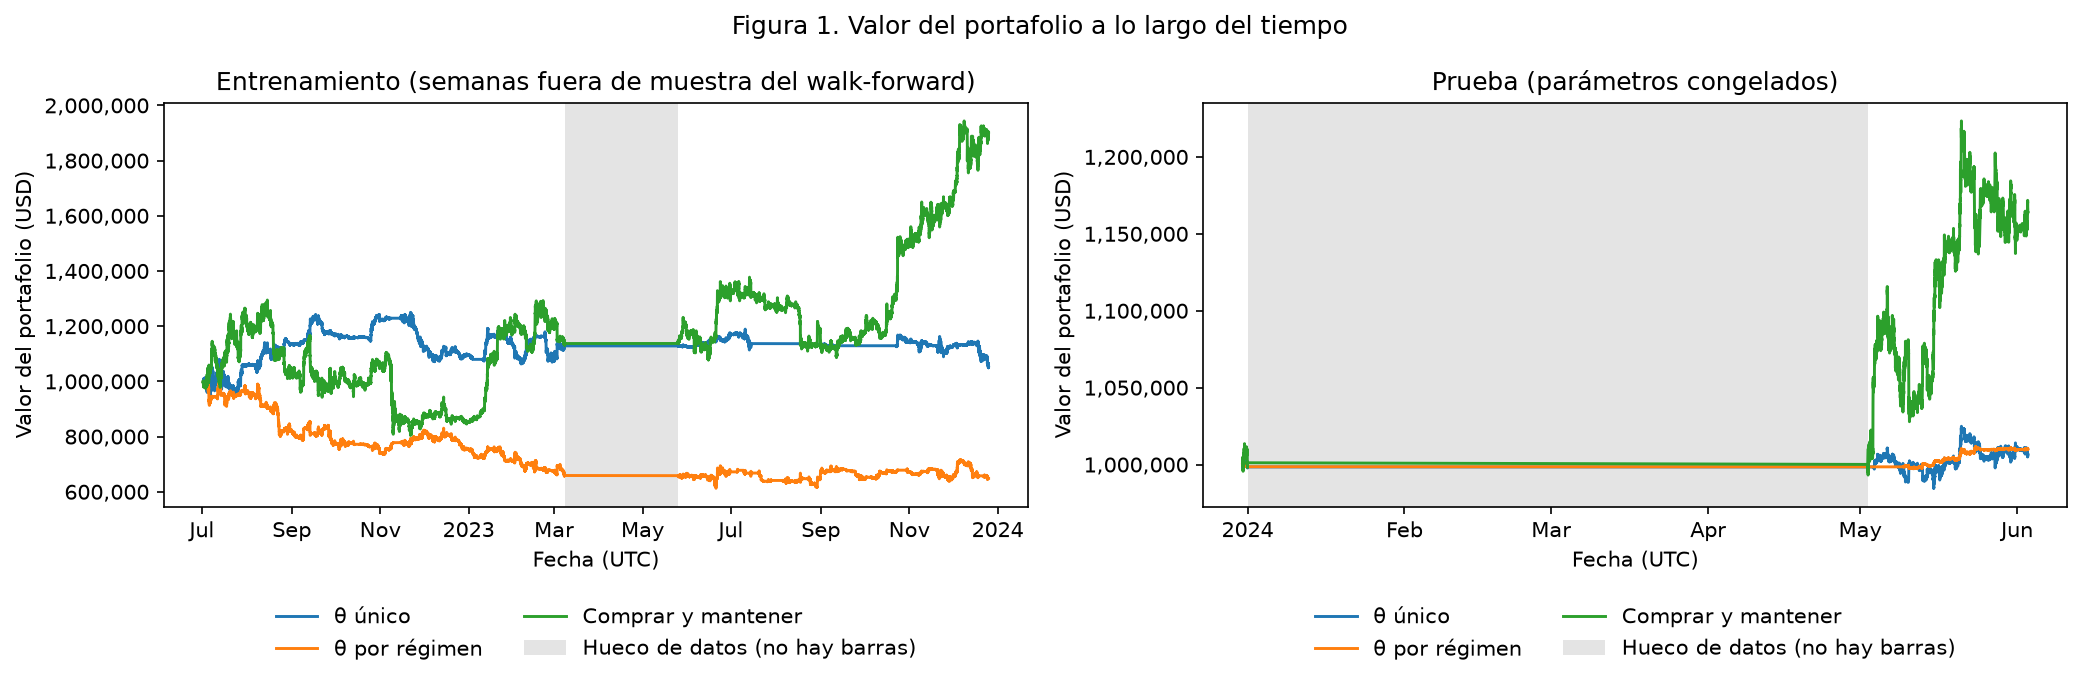

In [3]:
figure('fig1_valor_portafolio.png')

## 3. Figura 2. Drawdown

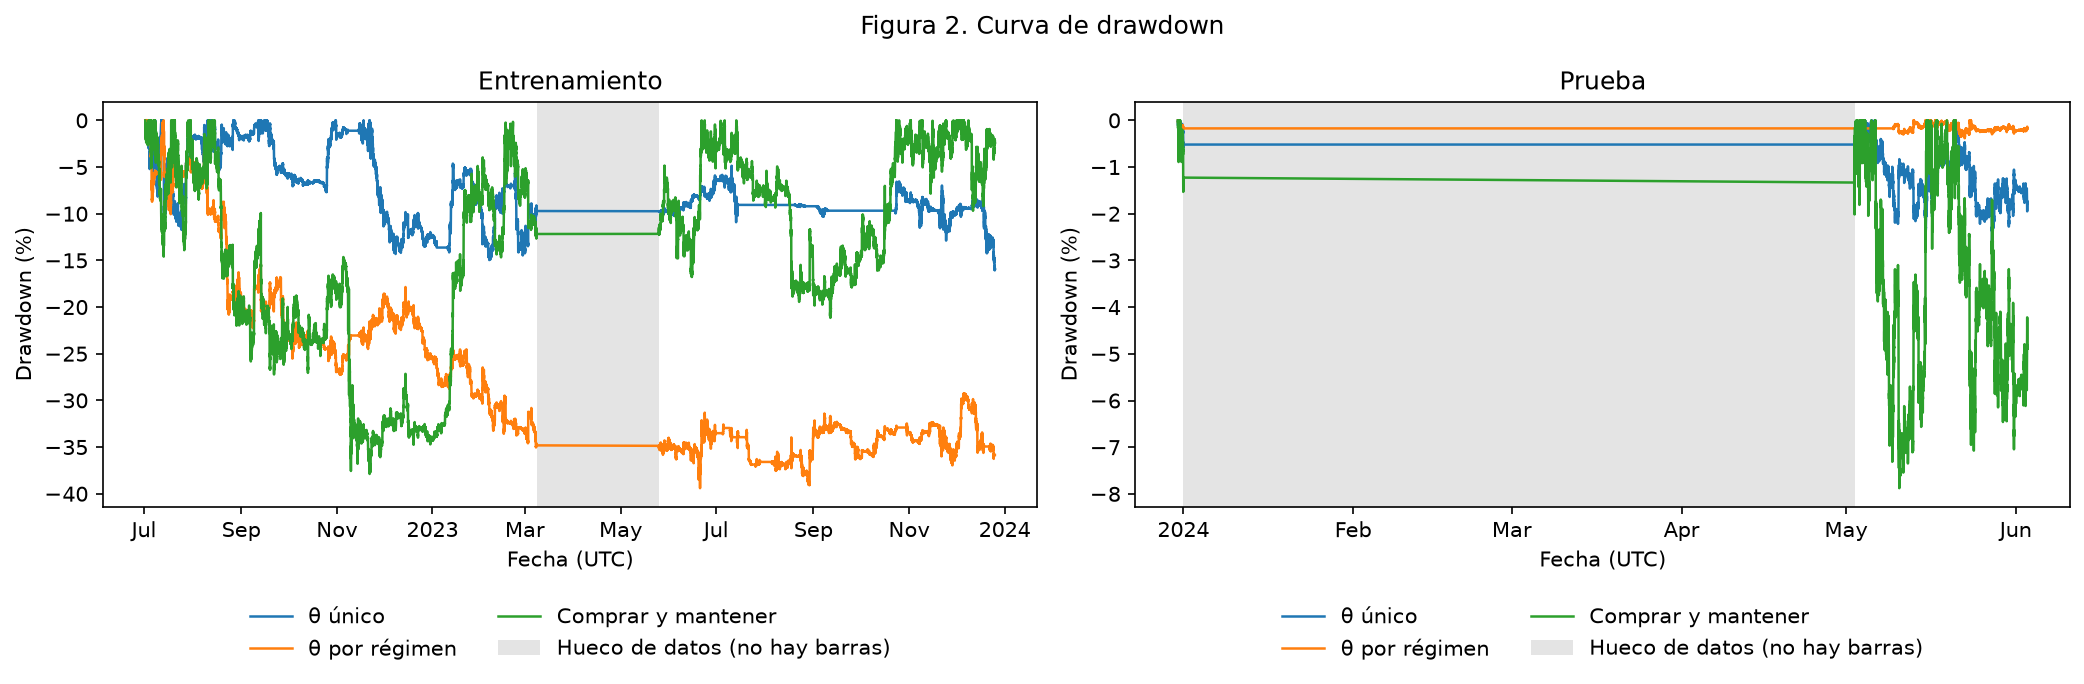

In [4]:
figure('fig2_drawdown.png')

## 4. Figura 3. Retornos mensuales, trimestrales y anuales

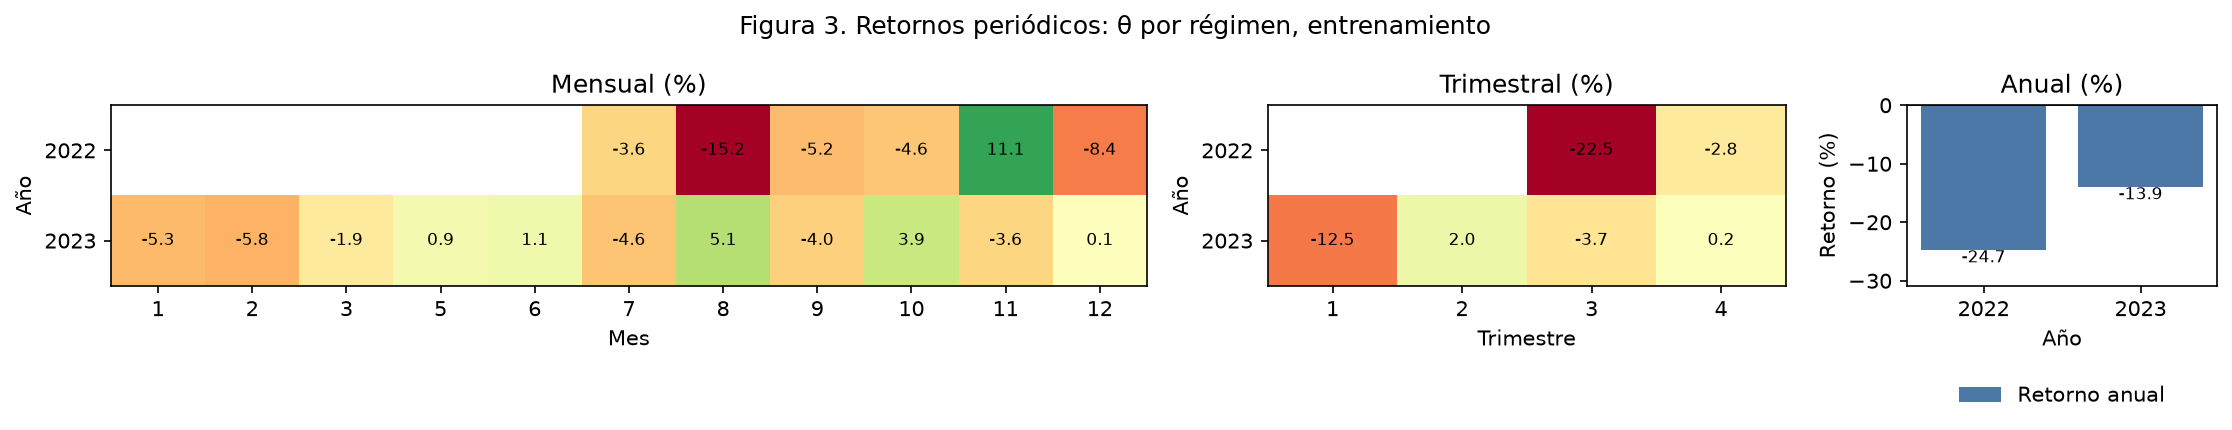

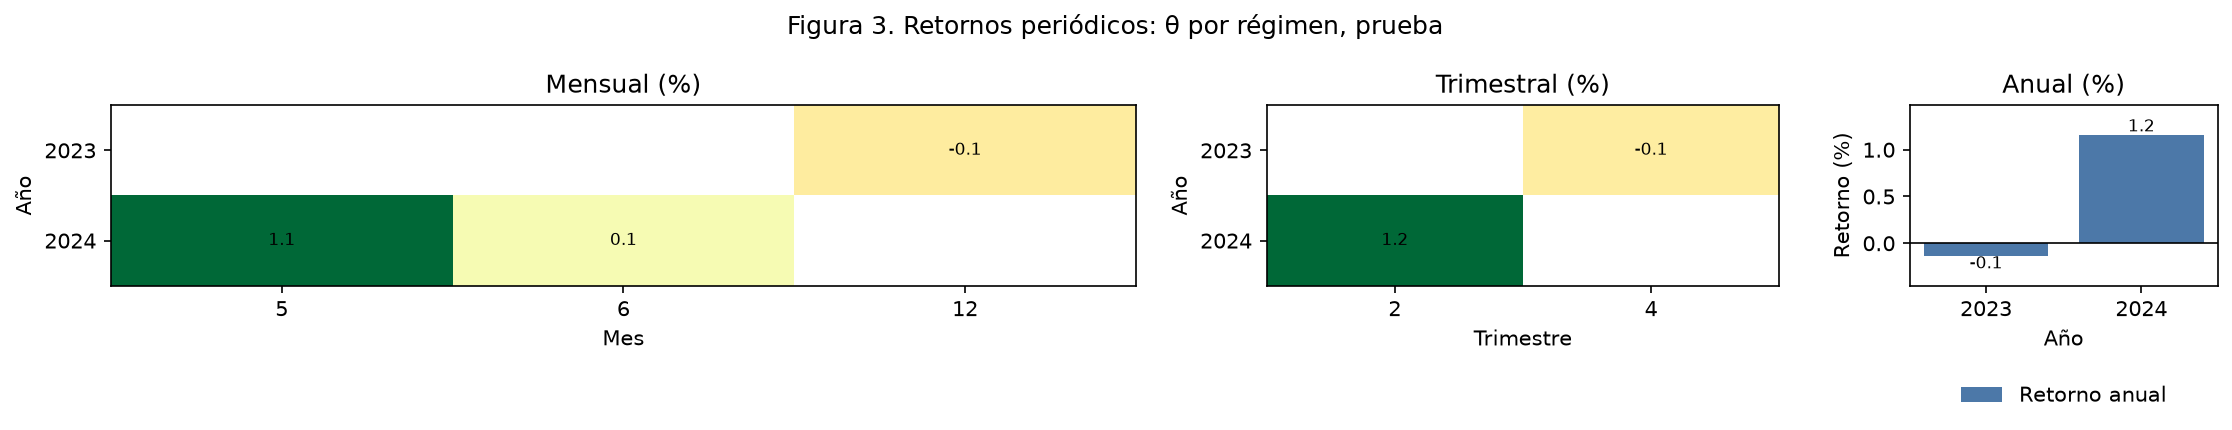

In [5]:
figure('fig3_retornos_entrenamiento.png')
figure('fig3_retornos_prueba.png')

## 5. Figura 4. Sensibilidad de los parámetros (±20%)

Redibujada con `plots.plot_sensitivity` a partir de la tabla guardada, en una carpeta temporal.

,base_calmar,base_retorno,calmar_-20%,retorno_-20%,calmar_+20%,retorno_+20%
n_donchian,3.4,0.754,3.939,0.853,3.355,0.716
n_roc,3.4,0.754,2.252,0.587,2.459,0.534
n_ema,3.4,0.754,3.395,0.753,3.403,0.755
n_atr,3.4,0.754,0.535,0.151,1.863,0.469
k,3.4,0.754,2.653,0.576,3.008,0.661
m,3.4,0.754,0.729,0.268,1.131,0.227
r,3.4,0.754,0.628,0.176,1.948,0.560
max_hold,3.4,0.754,0.764,0.242,1.684,0.358
risk_frac,3.4,0.754,3.098,0.574,3.678,0.934


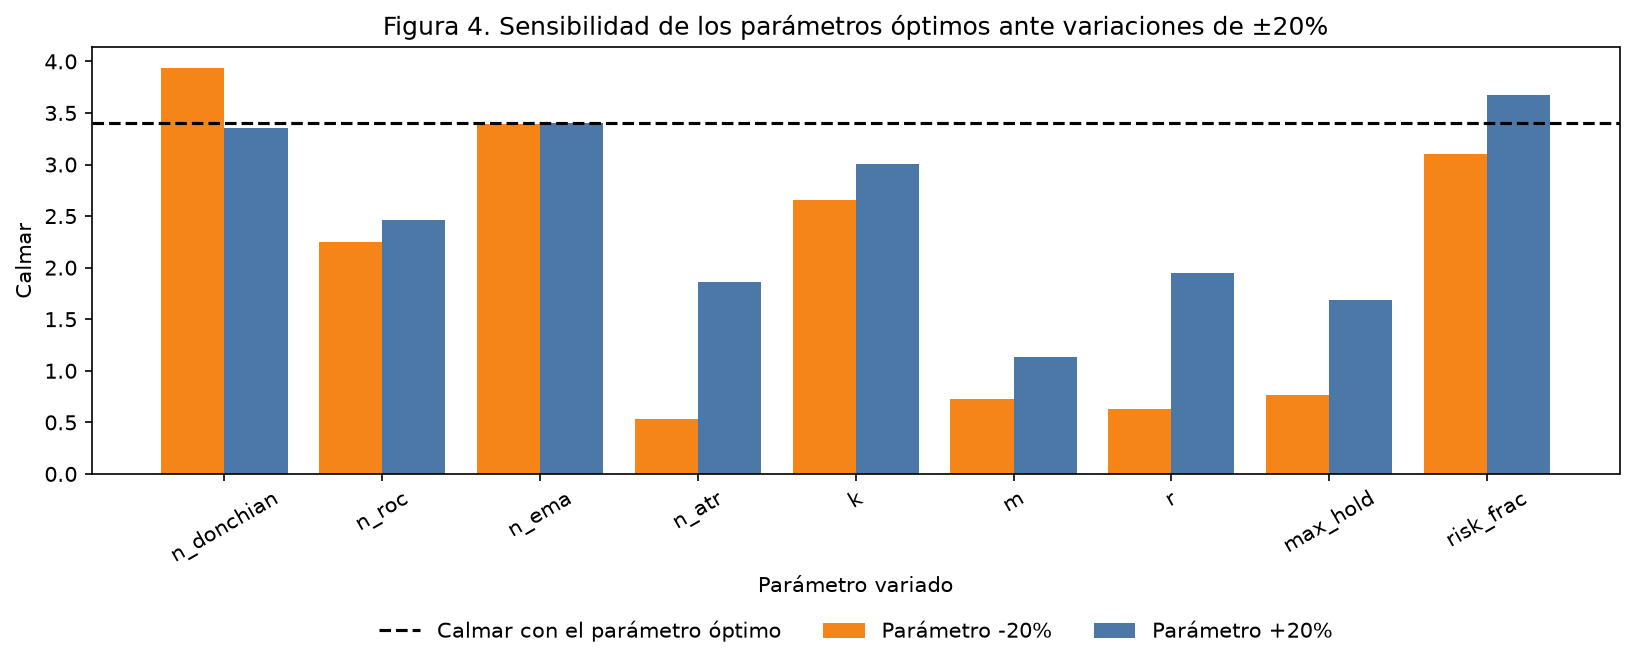

In [6]:
sens = table('pregunta3_sensibilidad')
display(sens.round(3))
plots.plot_sensitivity(sens, REDRAWN / 'fig4_sensibilidad.png')
figure('fig4_sensibilidad.png', REDRAWN)

## 6. Figura 5. Retorno contra costo de transacción

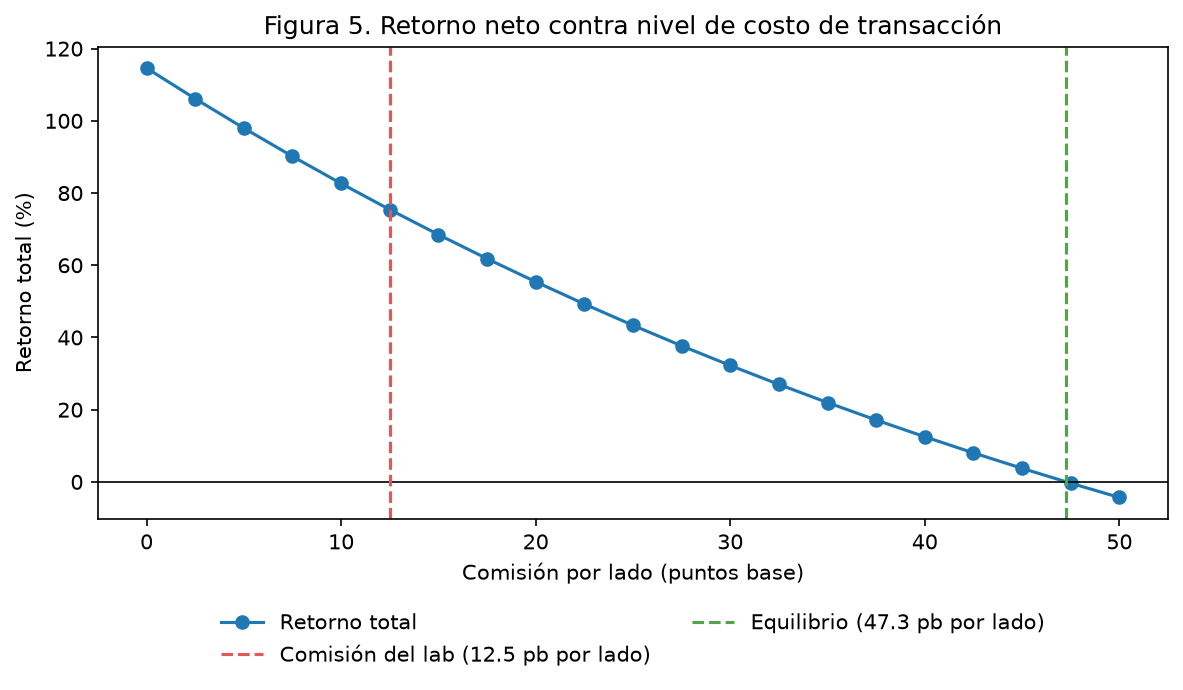

In [7]:
curve = table('pregunta4_curva_de_costos')
resumen = json.loads((TABLES / 'resumen.json').read_text())
plots.plot_cost_curve(curve, resumen.get('comision_equilibrio_bps_por_lado'), 12.5, REDRAWN / 'fig5_costos.png')
figure('fig5_costos.png', REDRAWN)

## 7. Figura 6. Regímenes de mercado

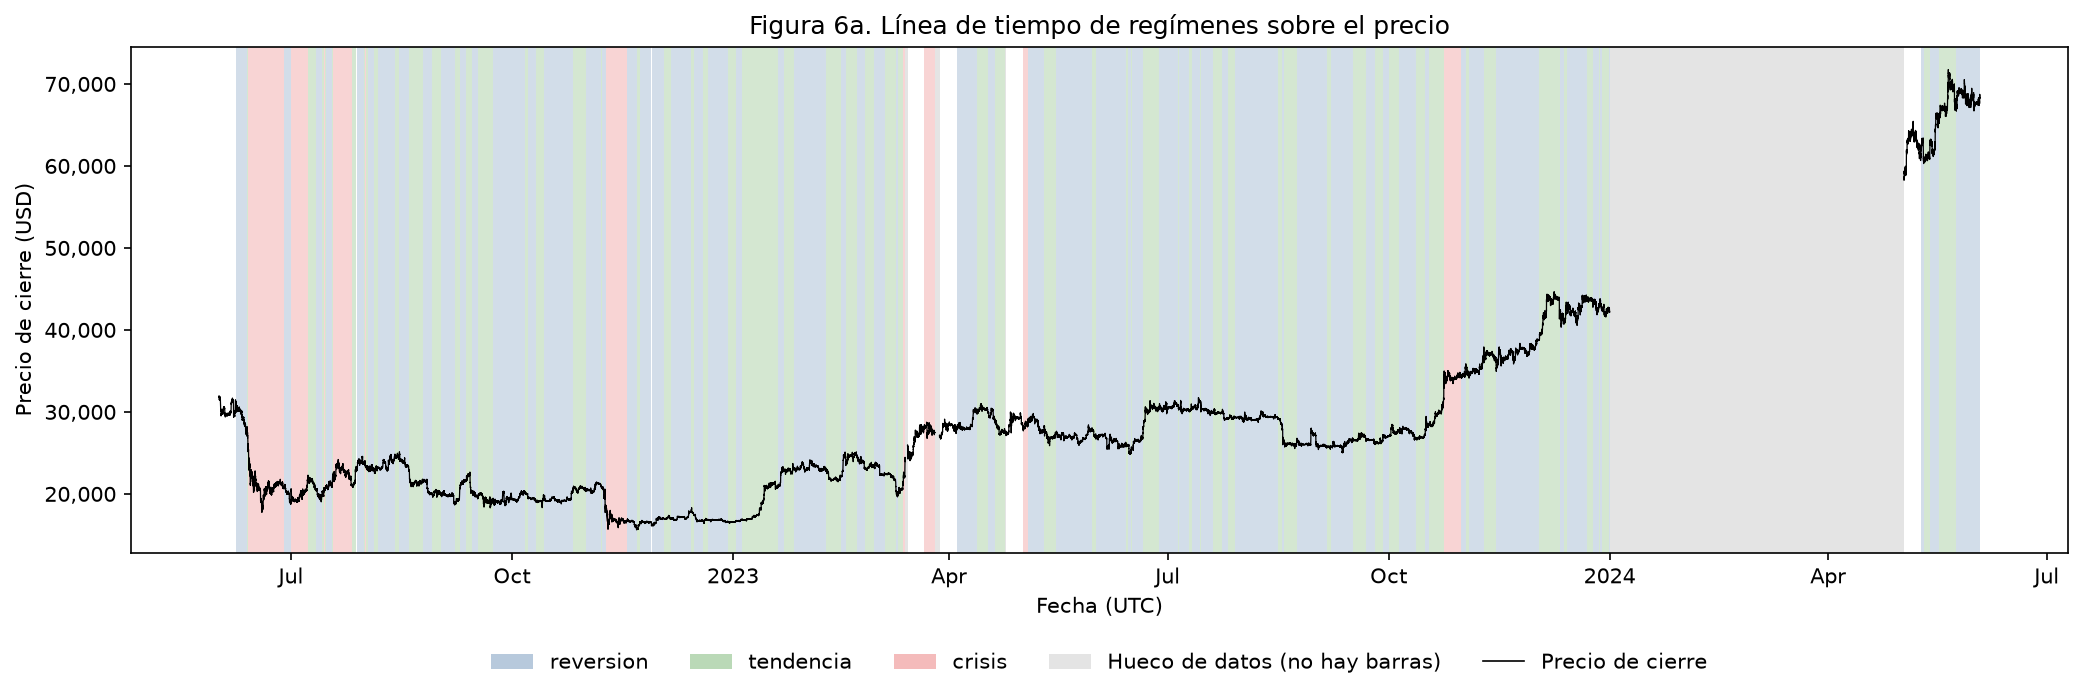

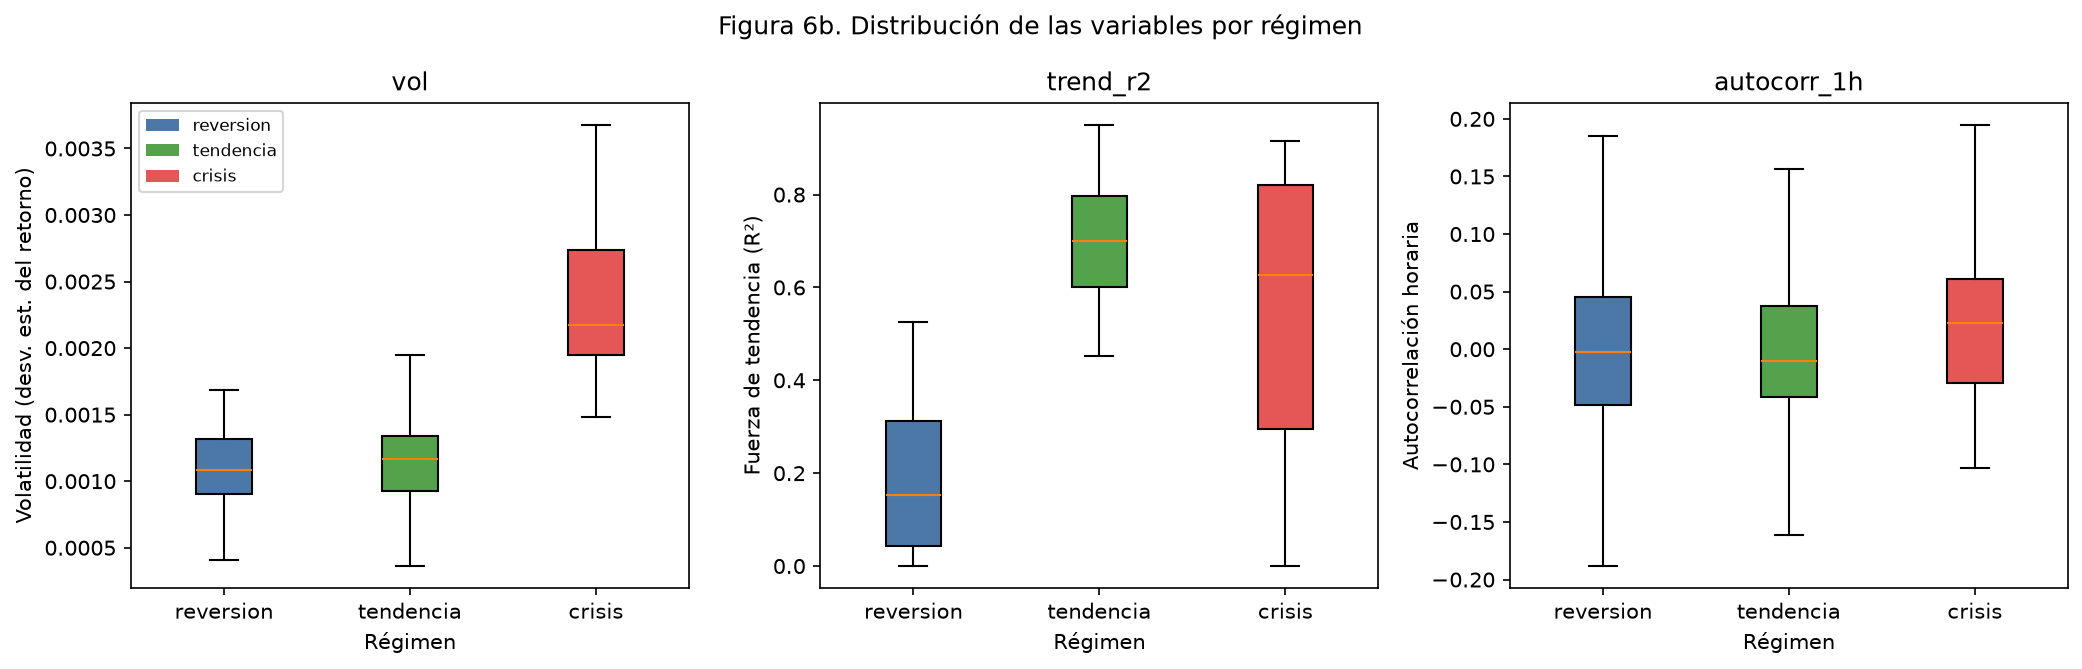

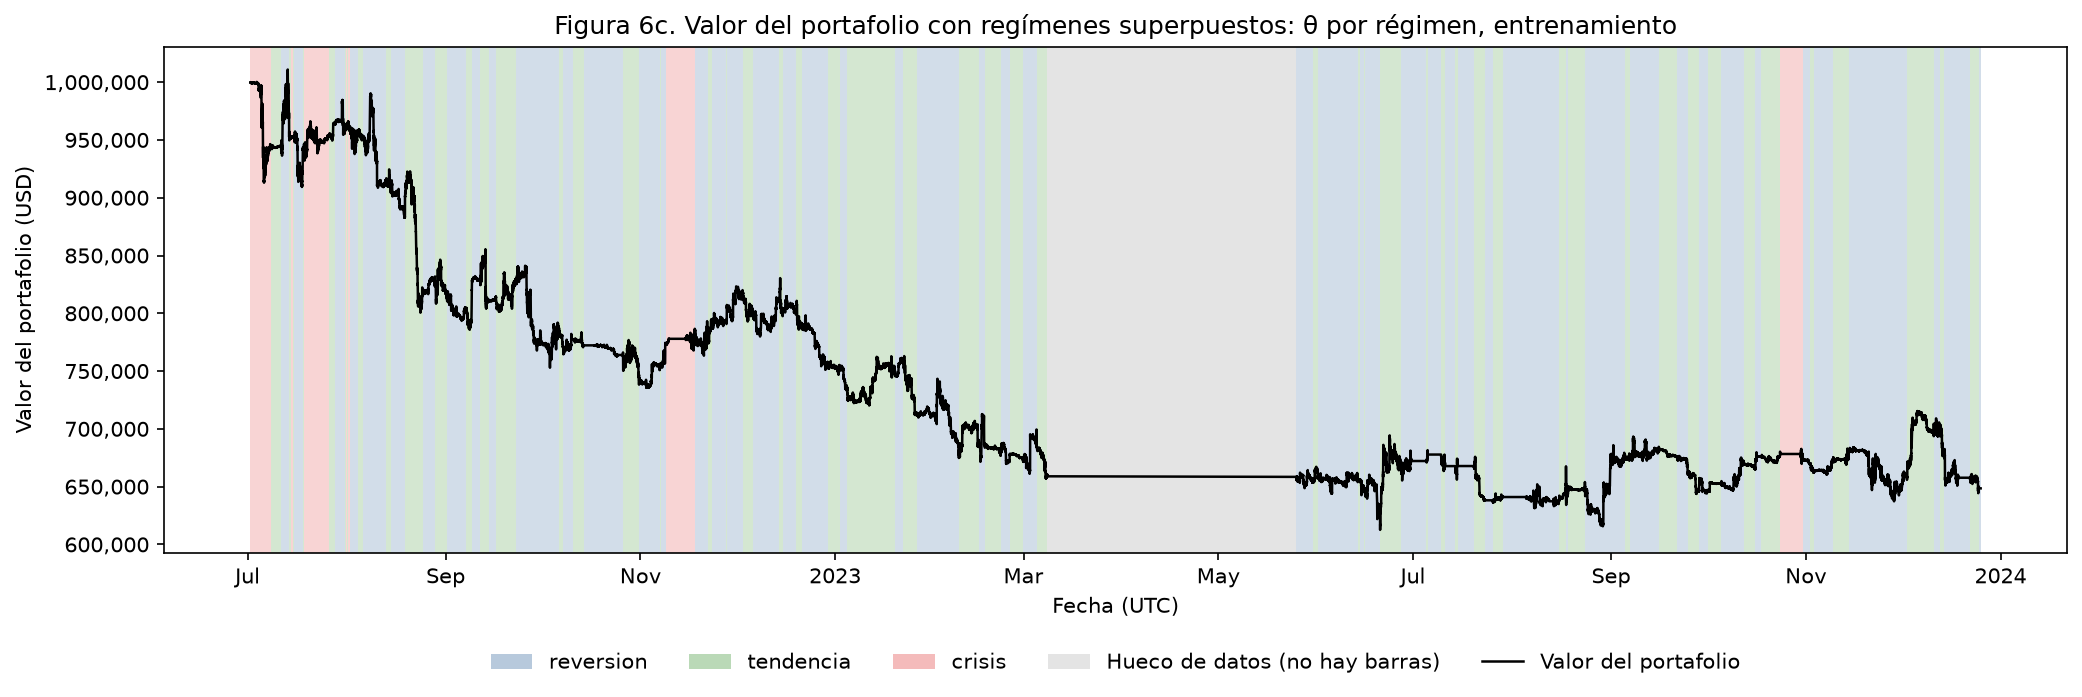

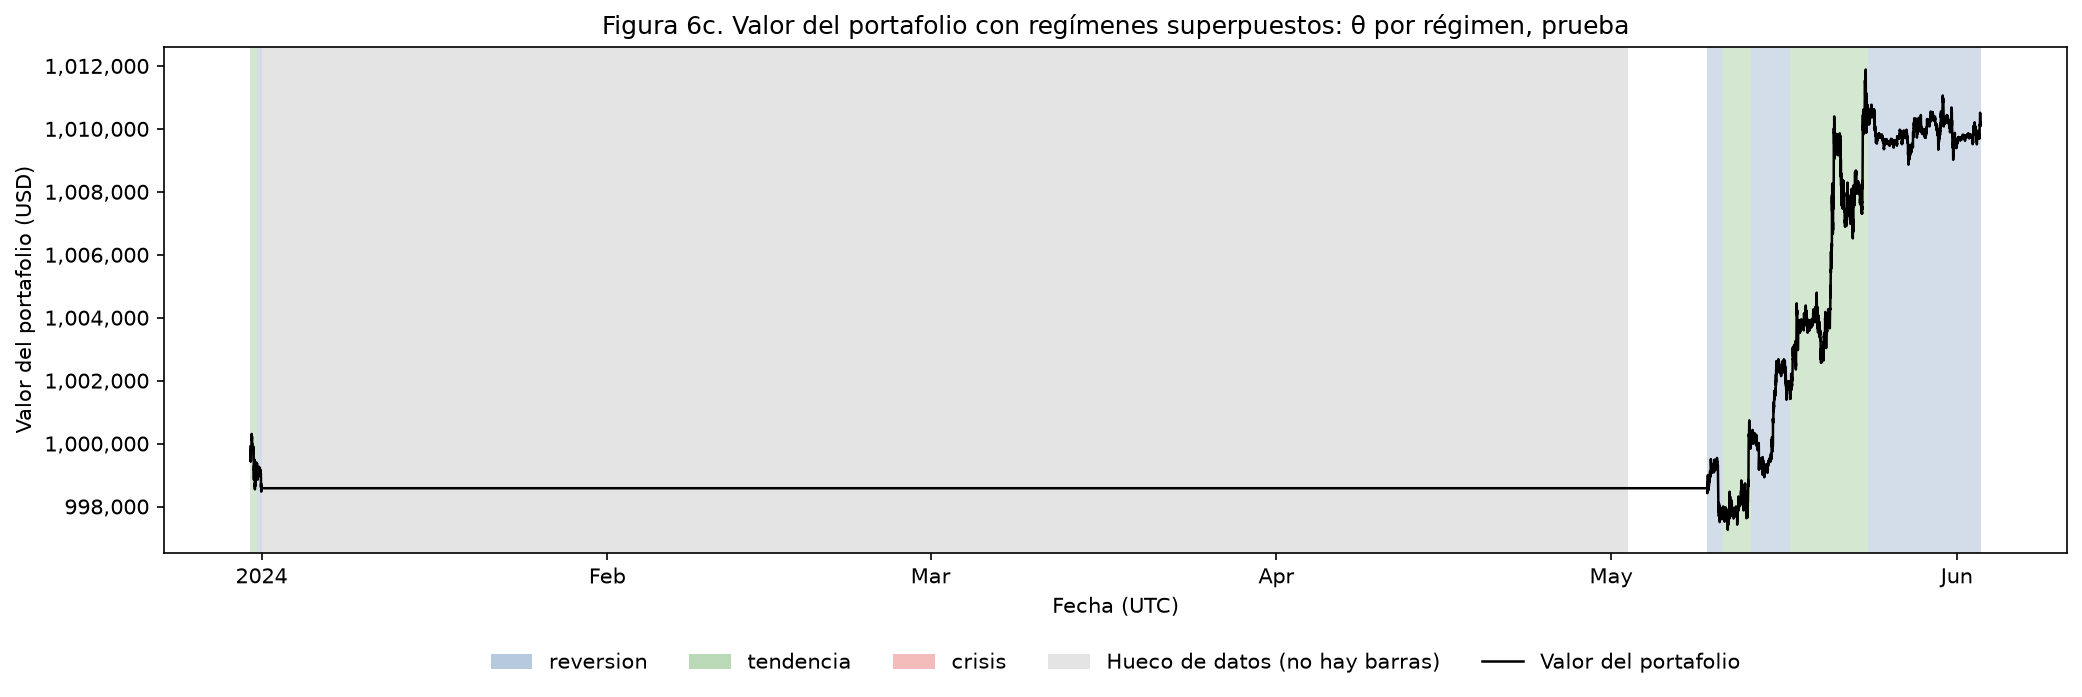

In [8]:
figure('fig6a_regimenes_precio.png')
figure('fig6b_distribuciones.png')
figure('fig6c_portafolio_regimenes_entrenamiento.png')
figure('fig6c_portafolio_regimenes_prueba.png')

## 8. Estabilidad del régimen, entrenamiento contra prueba

In [9]:
for name in ('train', 'test'):
    print(name)
    display(table(f'regimenes_{name}').round(1))

train


,participacion_%,duracion_media_h,duracion_mediana_h,rachas
reversion,57.1,122.1,94.0,60.0
tendencia,32.9,64.1,49.5,66.0
crisis,10.0,98.8,51.0,13.0


test


,participacion_%,duracion_media_h,duracion_mediana_h,rachas
reversion,60.6,92.8,59.5,4.0
tendencia,39.4,80.5,59.0,3.0
crisis,0.0,NaN,NaN,0.0


## 9. Desempeño por régimen y cómo terminan las operaciones

In [10]:
for dataset in ('train', 'test'):
    print(dataset)
    display(table(f'desempeno_por_regimen_{dataset}').round(3))
    display(table(f'salidas_por_motivo_{dataset}'))

train


,operaciones,win_rate,bruto_medio_pct,neto_medio_pct,neto_desv_pct,razon_media_desv,contribucion_capital_pct
regimen,,,,,,,
crisis,3,0.333,0.073,-0.176,0.817,-0.216,-0.606
reversion,235,0.366,0.249,-0.001,2.157,-0.001,-26.321
tendencia,192,0.380,0.230,-0.021,2.082,-0.010,-13.314


,operaciones
reason,
signal,131
regime_change,101
stop_loss,88
segment_end,56
take_profit,45
max_hold,9


test


,operaciones,win_rate,bruto_medio_pct,neto_medio_pct,neto_desv_pct,razon_media_desv,contribucion_capital_pct
regimen,,,,,,,
reversion,5,0.40,0.368,0.117,2.270,0.052,0.030
tendencia,4,0.75,3.028,2.775,2.994,0.927,0.981


,operaciones
reason,
regime_change,5
segment_end,2
max_hold,2


## 10. Selección de indicadores (sin mirar retornos)

Correlación media y máxima entre las señales de cada trío con un indicador por familia.

In [11]:
display(table('correlacion_trios').round(3))
display(table('correlacion_indicadores').round(2))

,correlacion_media,correlacion_maxima
ema_cross + rsi + keltner,0.582,0.724
ema_cross + roc + keltner,0.445,0.579
donchian + rsi + keltner,0.482,0.724
donchian + roc + keltner,0.358,0.579


,ema_cross,donchian,rsi,roc,keltner
ema_cross,1.00,0.69,0.59,0.32,0.44
donchian,0.69,1.00,0.40,0.17,0.32
rsi,0.59,0.40,1.00,0.69,0.72
roc,0.32,0.17,0.69,1.00,0.58
keltner,0.44,0.32,0.72,0.58,1.00


## 11. Exposición al mercado en la prueba

Fracción de barras con posición abierta y exposición media (nocional entre valor del portafolio). Explica por qué la volatilidad de las estrategias es tan baja.

In [12]:
path = TABLES / 'exposicion_test.csv'
if path.exists():
    display(pd.read_csv(path, index_col=0).round(1))
else:
    print('Corre python main.py para generar exposicion_test.csv')

,barras_con_posicion_%,exposicion_media_%,exposicion_maxima_%
theta_unico,96.2,29.2,38.4
theta_por_regimen,78.4,6.1,9.9


## 12. Respuestas con cifras propias

In [13]:
display(table('pregunta1_dos_de_tres').round(3))
print(json.dumps(resumen, indent=2))

,n_operaciones,retorno_total,calmar,sharpe,win_rate
donchian,179.0,0.269,0.996,1.036,0.408
roc,180.0,0.487,1.614,1.680,0.428
keltner,174.0,0.626,2.139,1.969,0.402
2 de 3,167.0,0.754,3.400,2.321,0.437


{
  "pruebas_por_ventana": 150,
  "ventanas": 65,
  "calmar_entrenamiento_mediano": 53.58531298573684,
  "calmar_fuera_de_muestra": 0.2545043703344041,
  "diferenciacion_reversion_vs_tendencia": {
    "diferencia_media": 0.019214578156262624,
    "p_welch": 0.9256824080571276,
    "ic95_bajo": -0.36932115958896083,
    "ic95_alto": 0.41731986100357155
  },
  "configuraciones_walk_forward_theta_unico": 9750,
  "configuraciones_walk_forward_por_regimen": 21450,
  "configuraciones_theta_congelado": 600,
  "comision_equilibrio_bps_por_lado": 47.282604258963616,
  "configuraciones_totales": 31800,
  "tiempo_total_s": 551
}
